# Chapter 15: The Foundation
Run a **real pretrained Chronos-T5-Tiny checkpoint** locally on the CPU.
No fitting or fine-tuning occurs here. We evaluate newly generated synthetic
series against a seasonal baseline and separately simulate benchmark leakage.
The simulation is not evidence that this checkpoint memorized any benchmark.

API verified against the [official model card](https://huggingface.co/amazon/chronos-t5-tiny)
and [Amazon repository](https://github.com/amazon-science/chronos-forecasting)
on 2026-09-18. Tiny is an 8.39M-parameter original Chronos model, chosen for
a small reproducible CPU lesson, not as the newest or strongest family member.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0, str(ROOT/'companion/src'))
from forecasting_companion.common import begin, save, plt, np
import pandas as pd
import torch
from chronos import ChronosPipeline
rng = begin(15)
torch.manual_seed(15)
torch.set_num_threads(1)

## Pin the pretrained artifact
First execution downloads roughly 34 MB of weights plus configuration into
the Hugging Face cache. Later runs reuse it. Network is needed only if the
checkpoint is absent. A download failure should fail visibly, never substitute
a random network. The commit pins weights independently of package versions.

In [2]:
MODEL_ID = 'amazon/chronos-t5-tiny'
REVISION = '29d808298f1a62493e7b9a5e08529d0d930fa189'
pipeline = ChronosPipeline.from_pretrained(
    MODEL_ID, revision=REVISION, device_map='cpu', dtype=torch.float32,
)
parameter_count = sum(p.numel() for p in pipeline.model.parameters())
assert parameter_count > 1_000_000
print({'model': MODEL_ID, 'revision': REVISION, 'parameters': parameter_count,
       'device': 'cpu', 'fine_tuning': False})

{'model': 'amazon/chronos-t5-tiny', 'revision': '29d808298f1a62493e7b9a5e08529d0d930fa189', 'parameters': 8394496, 'device': 'cpu', 'fine_tuning': False}


## Forecast only from the context
Both datasets below are synthetic, freshly generated with the lesson seed.
They contain weekly seasonality; one changes level at day 145, testing a
transition the model cannot know before it occurs. Similar pattern families
can be in pretraining even though these exact random realizations were not.
The context ends at each origin; targets are passed only to the evaluator.

Stable weekly 130 Chronos 80% coverage: 0.929
Stable weekly 144 Chronos 80% coverage: 0.643
Stable weekly 158 Chronos 80% coverage: 1.0
Stable weekly 172 Chronos 80% coverage: 0.643
Level shift 130 Chronos 80% coverage: 0.786
Level shift 144 Chronos 80% coverage: 0.071
Level shift 158 Chronos 80% coverage: 0.643
Level shift 172 Chronos 80% coverage: 0.929
model          Chronos tiny  Seasonal naive
series                                     
Level shift            5.83            5.09
Stable weekly          1.65            1.96


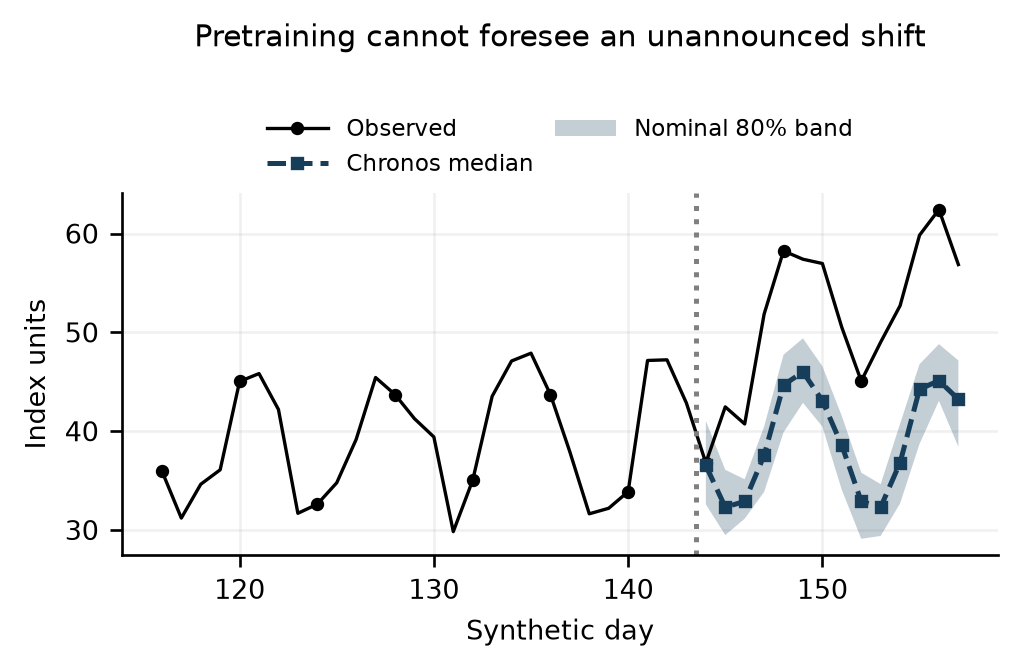

In [3]:
t = np.arange(190)
series = {'Stable weekly': 40+8*np.sin(2*np.pi*t/7)+rng.normal(0, 2, len(t)),
          'Level shift': 40+8*np.sin(2*np.pi*t/7)+12*(t >= 145)+rng.normal(0, 2, len(t))}
horizon, origins = 14, [130, 144, 158, 172]
contexts, cases = [], []
for label, values in series.items():
    for origin in origins:
        contexts.append(torch.tensor(values[origin-112:origin], dtype=torch.float32))
        cases.append((label, origin))
with torch.inference_mode():
    draws = pipeline.predict(contexts, prediction_length=horizon, num_samples=64).numpy()
assert draws.shape == (len(cases), 64, horizon)
assert np.isfinite(draws).all()
rows = []
for i, (label, origin) in enumerate(cases):
    truth = series[label][origin:origin+horizon]
    baseline = np.tile(series[label][origin-7:origin], 2)
    lo, median, hi = np.quantile(draws[i], [.1, .5, .9], axis=0)
    for model, prediction in [('Chronos tiny', median), ('Seasonal naive', baseline)]:
        rows.append(dict(series=label, origin=origin, model=model, mae=np.mean(abs(truth-prediction))))
    print(label, origin, 'Chronos 80% coverage:', round(np.mean((truth >= lo) & (truth <= hi)), 3))
scores = pd.DataFrame(rows)
print(scores.pivot_table(index='series', columns='model', values='mae').round(2).to_string())
fig, ax = plt.subplots()
case = cases.index(('Level shift', 144))
lo, med, hi = np.quantile(draws[case], [.1, .5, .9], axis=0)
ax.plot(t[116:158], series['Level shift'][116:158], label='Observed', color='black', linewidth=1)
ax.plot(np.arange(144,158), med, label='Chronos median')
ax.fill_between(np.arange(144,158), lo, hi, alpha=.25, label='Nominal 80% band')
ax.axvline(143.5, color='gray', linestyle=':')
ax.set(xlabel='Synthetic day', ylabel='Index units', title='Pretraining cannot foresee an unannounced shift')
ax.legend(fontsize=6)
save(15, 1, 'Actual zero-shot Chronos forecast',
     'CPU inference with pinned pretrained Chronos-T5-Tiny on a newly generated synthetic series. Context ends at day 143; the level changes at day 145. Bands summarize 64 sampled paths.',
     'Section One: The Bet That Paid Off', fig)

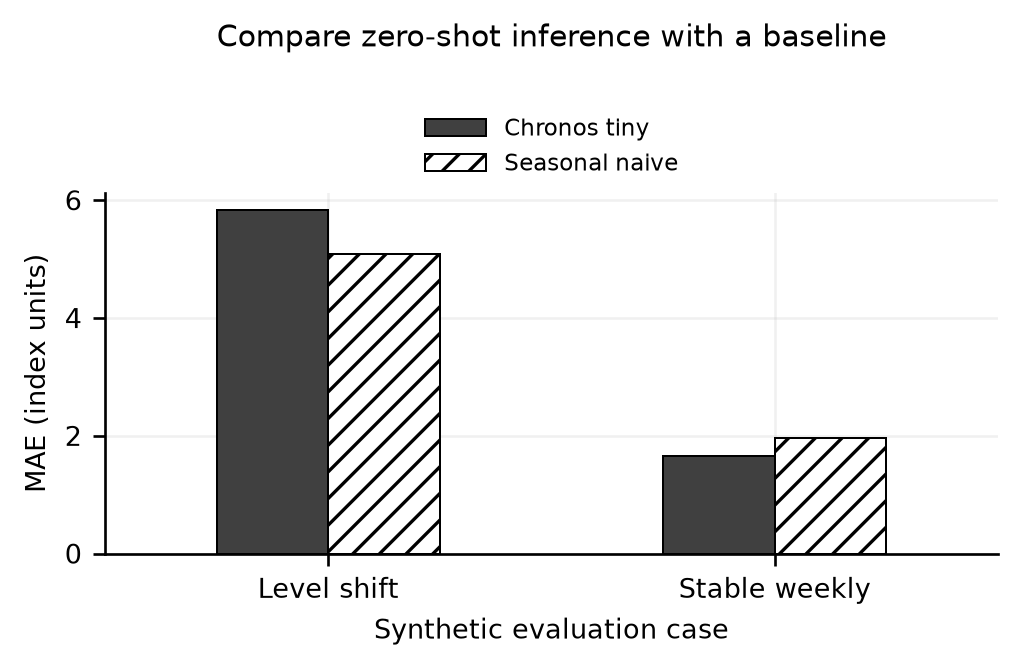

In [4]:
fig, ax = plt.subplots()
scores.pivot_table(index='series', columns='model', values='mae').plot.bar(ax=ax, rot=0)
ax.set(ylabel='MAE (index units)', xlabel='Synthetic evaluation case', title='Compare zero-shot inference with a baseline')
ax.legend(fontsize=6)
save(15, 2, 'Chronos versus seasonal naive',
     'Actual pretrained-model forecasts and a seven-day seasonal-naive baseline on two synthetic series, averaged over four fixed 14-day forecast origins. This tiny benchmark establishes no general model ranking.',
     'Section Five: What This Means in Practice', fig)

## A controlled contamination experiment, separate from Chronos
Create independent context–future pairs. A nearest-neighbor retrieval model
forecasts a future by finding the closest stored context. If the test pair
itself is inserted into its library, it can retrieve the answer exactly.
This deliberately invalid evaluation illustrates overlap, without modifying
Chronos or claiming knowledge of its pretraining membership.

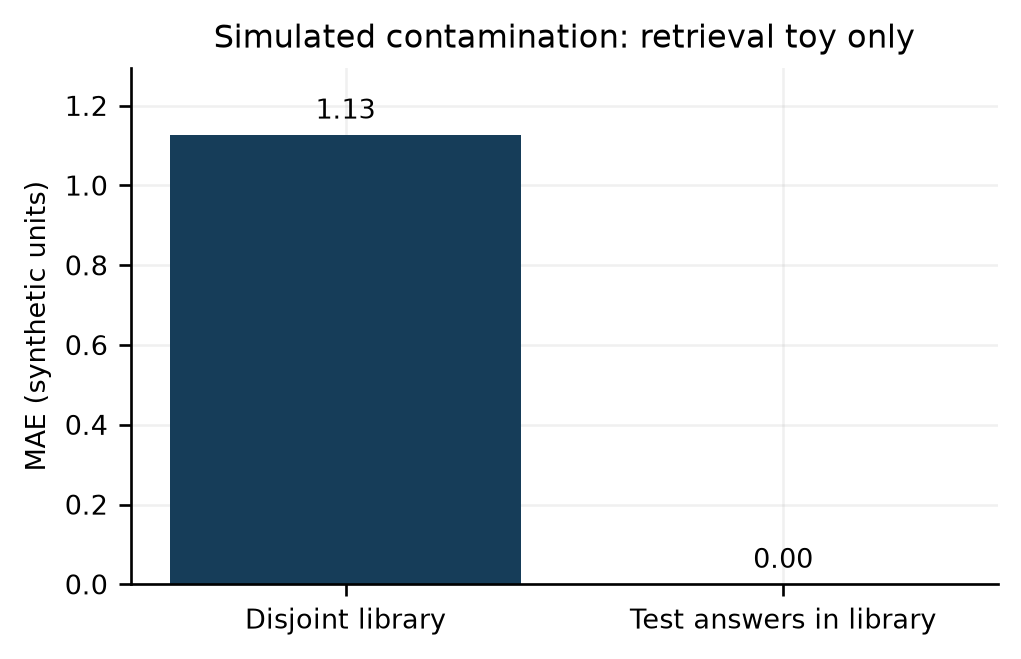

In [5]:
library_x = rng.normal(size=(100, 14))
library_y = rng.normal(size=(100, 7))
test_x = rng.normal(size=(30, 14))
test_y = rng.normal(size=(30, 7))
def retrieve(x, bank_x, bank_y):
    nearest = ((x[:, None, :]-bank_x[None, :, :])**2).sum(axis=2).argmin(axis=1)
    return bank_y[nearest]
clean_pred = retrieve(test_x, library_x, library_y)
leaked_pred = retrieve(test_x, np.vstack([library_x, test_x]), np.vstack([library_y, test_y]))
clean_error = np.mean(abs(clean_pred-test_y))
leaked_error = np.mean(abs(leaked_pred-test_y))
assert clean_error > 0 and leaked_error == 0
fig, ax = plt.subplots()
bars=ax.bar(['Disjoint library', 'Test answers in library'], [clean_error, leaked_error])
ax.bar_label(bars,fmt='%.2f',padding=3,fontsize=8)
ax.set_ylim(0,clean_error*1.15)
ax.set(ylabel='MAE (synthetic units)', title='Simulated contamination: retrieval toy only')
save(15, 3, 'Simulated benchmark contamination',
     'A separate nearest-neighbor toy achieves zero error when test context–future pairs are deliberately inserted into its library. This is not a Chronos score and does not diagnose its training corpus.',
     'Section Two: The Leakage Problem', fig)

## Limitations and exercise
This lesson validates an inference workflow, not state-of-the-art accuracy.
Eight cases are too few for broad rankings; sampled quantiles have Monte Carlo
error. Fixed seeds improve reproducibility but hardware/library changes can
alter sampling. Pattern similarity to pretraining is not itself test leakage.
No fine-tuning, external covariates, or real business data are used.
Exercise: preregister origins on a private series, lock this revision, record
when the data became available, and compare MAE and interval scores against
seasonal naive. Avoid selecting a checkpoint after inspecting the final test.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
A regular series with at least three seasons of history and 30 observations beyond the horizon. `checkpoint` is `tiny` (cached, pinned revision) by default; `mini` (about 80 MB), `small` (about 185 MB) and `base` (about 800 MB) download weights on first use, so state the size and get the reader's agreement before choosing one.

Minimal **format illustration**, not sufficient training data:

```csv
timestamp,target
2010-01-01,41.3
2010-02-01,41.8
2010-03-01,44.9
```

## Explain the mechanism

A pretrained forecasting model transfers patterns learned elsewhere. Zero-shot means no task-specific fitting in this workflow; it does not mean no relevant prior training or guaranteed superiority. Evaluation still needs a credible future test.

## Work through the arithmetic

For actuals [10,12], a model median [9,13] has MAE 1. A baseline [10,10] also has MAE 1. If the model’s nominal 80% intervals cover both values, the observed coverage is 2/2=100%, which is not enough to establish 80% calibration.

## Adapt the lesson to reader data

Replace the demonstration series and origin list, preserving past-only context. Keep the checkpoint pin from the source unless deliberately changing the experiment. Run the retrieval-contamination toy separately; it has a different method and should never be mixed into model scores.

For this chapter, settle these questions before fitting: Which checkpoint and revision will be fixed? When did the data become public? Are private later data available? What context, horizon and baseline are appropriate? Can the environment run the actual dependency?

## Interpret the actual lesson outputs

The source uses actual pinned Chronos inference. Its small evaluation consists of two series and eight cases and can legitimately lose to its baseline. The separate nearest-neighbor contamination illustration inserts test pairs deliberately; it neither measures nor diagnoses Chronos training overlap.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `timestamp,forecast,q10,q50,q90`.
- `summary.json`: `checkpoint,model_id,revision,download_warning,origins,per_origin,engine_baselines,test_mae,test_coverage,mean_latency_s,quantiles,samples` plus method, interpretation, assumptions, not_done and status.

The tool runs Chronos-T5 zero-shot in a separate worker process (so it can share a session with LightGBM), sampling `samples` paths and reporting the requested `quantiles` at `origins` expanding origins plus the untouched final holdout: median MAE, coverage of the outer quantile band and latency per call. It runs the engine's baseline pool (naive, seasonal naive, drift, equal ensemble) at exactly the same origins and reports both leaderboards side by side, then issues the future forecast from full history. No fine-tuning, no covariates, and no certification that the series was absent from pretraining. The tool runs only when asked; the assistant decides, with the reader, whether the method fits before running it.

## Decide what the evidence supports

A frozen model avoids local fitting leakage but may still have unknown pretraining exposure. A contamination toy is not evidence of contamination in a particular checkpoint. Sample quantiles have Monte Carlo error; few cases cannot establish a broad ranking.

If downloads or the dependency are unavailable, return baseline forecasts and an explicit not-run status for the foundation model. Never substitute a generic smoother and call it Chronos. If overlap is unknown, preserve the uncertainty and prioritize later private data.

The applied deliverable must make these items inspectable: `results.csv` columns: `timestamp,forecast,q10,q50,q90`; `summary.json` keys: `checkpoint,model_id,revision,download_warning,origins,per_origin,engine_baselines,test_mae,test_coverage,mean_latency_s,quantiles,samples` plus method, interpretation, assumptions, not_done and status. Report the pretrained model beside the seasonal naive at the same origins; a model that does not beat the seasonal naive on this series has not earned the download.

## Three exercises with worked solutions

### Exercise 1

The baseline beats Chronos on the frozen test. Should a new checkpoint be selected on that same test?

**Worked solution.** No. Report the result; selecting again uses that test as validation and requires a new untouched test.

### Exercise 2

A known pattern resembles training data. Does that prove leakage?

**Worked solution.** No. Similarity alone is not evidence that the exact evaluation future was exposed.

### Exercise 3

Download fails but seasonal-naive runs. What method label belongs on its output?

**Worked solution.** Seasonal naive, with foundation-model execution marked skipped or failed.

## Business-reader application

Use this request with the skill:

> Use chapter 15 to benchmark the pinned foundation model on demand.csv with frozen origins, honest dependency status and matched baseline and interval scores.

## Observed-data transfer exercise

A bundled [observed series](../data/observed/monthly-temperature.csv) and [matching config](../configs/ch15-observed.json) provide a second application after the controlled fixture. Read the [data registry](../data/registry.json) for provenance and transformations. These are historical snapshots, not archived real-time release vintages.

```bash
companion/.venv/bin/python companion/scripts/run.py apply --chapter 15 \
  --input companion/data/observed/monthly-temperature.csv \
  --config companion/configs/ch15-observed.json \
  --output companion/applied-runs/ch15-observed-reader
```

Compare the fixed checkpoint with seasonal-naive, preserving a loss even if the foundation model loses. Record the actual result of your run. Do not import the controlled example’s winner or interpret a successful numerical execution as evidence of operational accuracy.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [6]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch15.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch15.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(15, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch15-workshop-results.csv', index=False)
_ = (workshop_output/'ch15-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Chronos-T5 tiny zero-shot forecast
Status: passed

Interpretation: Chronos tiny: mean median-MAE over 3 selection origins 2.481 vs engine baselines Seasonal naive 2.908, Equal ensemble 4.916, Naive 6.567, Drift 6.604; final holdout MAE 2.763, coverage of the 0.1-0.9 band 67%. Mean latency 0.13 s per call on CPU. Pretraining overlap with this series is not certified; one holdout cannot establish calibration.

Assumptions:
  - Series treated as univariate without covariates
  - Sampled quantiles from the pretrained model at the given seed
Not done:
  - No fine-tuning
  - No covariates
  - Pretraining corpus exclusion not verified

Evidence:
  checkpoint: tiny
  model_id: amazon/chronos-t5-tiny
  revision: 29d808298f1a62493e7b9a5e08529d0d930fa189
  origins: [2017-12-01 00:00:00+00:00, 2018-12-01 00:00:00+00:00, 2019-12-01 00:00:00+00:00, 2020-12-01 00:00:00+00:00]
  per_origin: <4 rows>
  engine_baselines: Seasonal naive=2.908, Equal ensemble=4.916, Naive=6.567, Drift=6.604
  test

## The same workflow on observed data

A second run on a bundled public-domain series documented in `data/registry.json` (a revised
historical snapshot, not an archived real-time vintage). The earlier time cuts prevent fitting
on held-out outcomes; they do not undo revisions made before the snapshot was published.
Compare this digest with the controlled case above: a method need not win to be useful, and
the winner on synthetic data has no claim on observed data.

In [7]:
observed_input = pd.read_csv(project_path/'companion/data/observed/monthly-temperature.csv')
observed_config = json.loads((project_path/'companion/configs/ch15-observed.json').read_text())
observed_table, observed_summary = analyze_chapter(15, observed_input, observed_config)
print('Observed-data source:', observed_config['source'])
print(summarize(observed_summary, observed_table))
print()
print(preview(observed_table))
observed_table.to_csv(workshop_output/'ch15-observed-results.csv', index=False)
_ = (workshop_output/'ch15-observed-summary.json').write_text(json.dumps(clean_json(observed_summary), indent=2)+'\n')

Observed-data source: Public-domain statsmodels El Niño observations, 1950–2010; historical revised snapshot
Method: Chronos-T5 tiny zero-shot forecast
Status: passed

Interpretation: Chronos tiny: mean median-MAE over 3 selection origins 0.8456 vs engine baselines Seasonal naive 1.147, Equal ensemble 1.826, Naive 2.3, Drift 2.308; final holdout MAE 1.277, coverage of the 0.1-0.9 band 50%. Mean latency 0.23 s per call on CPU. Pretraining overlap with this series is not certified; one holdout cannot establish calibration.

Assumptions:
  - Series treated as univariate without covariates
  - Sampled quantiles from the pretrained model at the given seed
Not done:
  - No fine-tuning
  - No covariates
  - Pretraining corpus exclusion not verified

Evidence:
  checkpoint: tiny
  model_id: amazon/chronos-t5-tiny
  revision: 29d808298f1a62493e7b9a5e08529d0d930fa189
  origins: [2006-12-01 00:00:00+00:00, 2007-12-01 00:00:00+00:00, 2008-12-01 00:00:00+00:00, 2009-12-01 00:00:00+00:00]
  per_orig